In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# 1. TẢI DỮ LIỆU
file_path = "merged/data.csv"
df = pd.read_csv(file_path)


In [2]:
# Explore kiểu dữ liệu của tất cả các cột
try:
    
    print(" TỔNG QUAN DỮ LIỆU:")
    
    # Xem chi tiết 
    df.info()
    
    # In ra 5 dòng ngẫu nhiên để xem chuỗi "10%" hay "10" 
    print(df.sample(5))

except FileNotFoundError:
    print("Không tìm thấy file csv.")

 TỔNG QUAN DỮ LIỆU:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19817 entries, 0 to 19816
Data columns (total 29 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   product_id                    19817 non-null  int64  
 1   product_name                  19817 non-null  object 
 2   product_url                   19817 non-null  object 
 3   category_id                   19817 non-null  int64  
 4   category_name                 19817 non-null  object 
 5   category_root_name            19817 non-null  object 
 6   price                         19811 non-null  float64
 7   original_price                19811 non-null  float64
 8   discount_rate                 19811 non-null  float64
 9   quantity_sold                 14172 non-null  float64
 10  rating_average                19811 non-null  float64
 11  review_count                  19811 non-null  float64
 12  is_return_policy              19811 non-

Ta thấy được `return_rate` và `cancel_by_seller_rate` chưa đúng với định dạng float của tỉ lệ. Có dòng dữ liệu đang chứa thêm kí tự "%" còn có dòng thì không.

In [3]:
# SỬA ĐỔI KIỂU DỮ LIỆU (DATA TYPE CONVERSION)

# Hàm xử lý các cột % (có ký tự %) thành số thực (float)
def clean_percentage(x):
    """Hàm làm sạch chuỗi phần trăm: '12%' -> 12.0, '<1%' -> 0.5"""
    if pd.isna(x): 
        return 0.0
    x = str(x).strip()
    
    # Xử lý trường hợp đặc biệt "<1%"
    if '<' in x:
        return 0.5 # Gán giá trị nhỏ tượng trưng
    
    # Loại bỏ ký tự % và chuyển sang float
    clean_val = x.replace('%', '').replace(' ', '')
    try:
        return float(clean_val)
    except:
        return 0.0

# Áp dụng cho 2 cột tỷ lệ
df['cancel_by_seller_rate'] = df['cancel_by_seller_rate'].apply(clean_percentage)
df['return_rate'] = df['return_rate'].apply(clean_percentage)

# Chuyển đổi các cột số khác để chắc chắn 
cols_to_numeric = ['price', 'original_price', 'quantity_sold', 'total_follower', 'review_count']
for col in cols_to_numeric:
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

print(df[['cancel_by_seller_rate', 'return_rate']].dtypes)

cancel_by_seller_rate    float64
return_rate              float64
dtype: object


# Feature engineering

- `reputation_score`: điểm uy tín thực sự giữa `rating_average` và `review_count` (Rating 5 sao mà chỉ có 1 review thì không bằng 4.5 sao mà có 1000 review.)
- `trust_level`: điểm tín nhiệm là tổng giữa các flag uy tín `is_official`, `is_authentic` và `is_brand`
- `review_to_sold_ratio`: tỉ lệ tương tác so với lượt mua (`review_count`/(`quantity_sold`+1))
- `shop_potential`: đo độ nổi tiếng của shop dựa trên tổng của `store_review_count` và `total_follower`

***Phục vụ cho câu hỏi 1, 8 và 10***
- `name_length`: độ dài của tiêu đề
- `has_hot_keywords`: kiểm tra tiêu đề có chứa những từ khóa giật tít hay không. Kết quả sẽ trả về dạng nhị phân 1: Có và 0: Không.

***Phục vụ cho câu hỏi 2***
- `total_visuals`: tổng số lượng video và hình ảnh
- `has_video`: flag kiểm tra sản phẩm có video không

***Phục vụ cho câu hỏi 3***
- `discount_amount`: số tiền giảm thực tế (hiệu của `original_price` và `price`)
- `price_vs_category`: giá tương đối của sản phẩm so với danh mục, so sánh giá sản phẩm so với giá trung bình của tất cả các sản phẩm cùng danh mục. <1: rẻ hơn trung bình; >1: mắc hơn trung bình.
- `is_charm_price`: flag kiểm tra giá tiền có hiệu ứng đuôi 999 hay không

***Phục vụ cho câu hỏi 5 và 7***
- `shop_risk_score`: tổng tỉ lệ giữa hoàn trả và hủy đơn
- `is_big_shop`: flag cho những shop có lượng follower >10.000 là big shop

***Tạo biến mục tiêu dự đoán hành vi mua hàng***
- `is_successful`: dùng mức trung vị của số lượng bán làm ngưỡng cắt. Nếu lớn hơn thì giá trị là 1: Success, ngược lại là 0: Fail.

In [4]:
# ==============================================================================
# 1. NHÓM UY TÍN & CHẤT LƯỢNG (TRUST & QUALITY)
# ==============================================================================

df['reputation_score'] = df['rating_average'] * np.log1p(df['review_count'])
df['trust_level'] = (df['is_official'] + 
                     df['is_authentic']+ 
                     df['is_brand'])
df['review_to_sold_ratio'] = df['review_count'] / (df['quantity_sold'] + 1)
df['shop_potential'] = (df['store_review_count'] + df['total_follower'])

# ==============================================================================
# 2. NHÓM NỘI DUNG & SEO (CONTENT)
# ==============================================================================
df['name_length'] = df['product_name'].astype(str).apply(len)

keywords = ['freeship', 'chính hãng', 'cao cấp', 'xịn', 'hot', 'giảm', 'sale', 'tặng', 'combo']
pattern = '|'.join(keywords)
df['has_hot_keywords'] = df['product_name'].astype(str).str.lower().str.contains(pattern).astype(int)

df['total_visuals'] = df['image_count'] + df['video_count']
df['has_video'] = df['video_count'].apply(lambda x: 1 if x > 0 else 0)


# ==============================================================================
# 3. NHÓM GIÁ & TÂM LÝ (PRICING PSYCHOLOGY)
# ==============================================================================
df['discount_amount'] = df['original_price'] - df['price']
# Xử lý lỗi nếu discount âm
df['discount_amount'] = df['discount_amount'].apply(lambda x: x if x > 0 else 0)


if 'category_root_name' in df.columns:
    df['category_avg_price'] = df.groupby('category_root_name')['price'].transform('mean')
    df['price_vs_category'] = df['price'] / (df['category_avg_price'] + 1)
else:
    df['price_vs_category'] = 1.0 # Mặc định nếu không có category

def is_charm_price(x):
    s = str(int(x))
    return 1 if s.endswith('9') or s.endswith('900') or s.endswith('9000') else 0
df['is_charm_price'] = df['price'].apply(is_charm_price)


# ==============================================================================
# 4. NHÓM RỦI RO VẬN HÀNH (RISK SCORE)
# ==============================================================================

df['shop_risk_score'] = df['cancel_by_seller_rate'] + df['return_rate']
df['is_big_shop'] = df['total_follower'].apply(lambda x: 1 if x > 10000 else 0)


# ==============================================================================
# 5. BIẾN MỤC TIÊU (TARGET VARIABLE)
# ==============================================================================

# Tạo nhãn phân lớp: Sản phẩm Thành công (1) vs Thất bại (0)
# Dùng mức trung vị (median) của số lượng bán làm ngưỡng cắt
threshold = df['quantity_sold'].median()
if threshold == 0: threshold = 1 

df['is_successful'] = df['quantity_sold'].apply(lambda x: 1 if x >= threshold else 0)

print("✅ Đã bổ sung xong tất cả các Feature cần thiết.")
print(f"Ngưỡng xác định sản phẩm thành công (is_successful=1): Bán >= {threshold}")

# Thêm các feature mới tạo vào dataframe
adding_features = [
    # Feature Mới Tạo (Engineered)
    'reputation_score', 'trust_level', 'review_to_sold_ratio',
    'name_length', 'has_hot_keywords', 'total_visuals', 'has_video',
    'price_vs_category', 'is_charm_price', 'discount_amount',
    'shop_risk_score', 'is_big_shop', 'shop_potential',
    'is_successful'
]

# Lọc chỉ lấy các cột này (nếu muốn gọn nhẹ) hoặc giữ nguyên df
df_final = df[adding_features].update(df)
print(f"📊 Kích thước: {df.shape}")
print(df.head(3))

✅ Đã bổ sung xong tất cả các Feature cần thiết.
Ngưỡng xác định sản phẩm thành công (is_successful=1): Bán >= 5.0
📊 Kích thước: (19817, 44)
   product_id                                     product_name  \
0   276641167                 Xe máy Honda Vision 2025 Cao Cấp   
1   276626995   Xe Máy Honda Vision 2025 - Phiên Bản Thể Thao   
2   276626834  Xe Máy Honda Vision 2025 - Phiên Bản Đặc Biệt   

                                         product_url  category_id  \
0  https://tiki.vn/xe-may-honda-vision-2025-cao-c...         8597   
1  https://tiki.vn/xe-may-honda-vision-2025-phien...         8597   
2  https://tiki.vn/xe-may-honda-vision-2025-phien...         8597   

  category_name      category_root_name       price  original_price  \
0        Xe máy  Ô Tô – Xe Máy – Xe Đạp  34500000.0      34600000.0   
1        Xe máy  Ô Tô – Xe Máy – Xe Đạp  38659000.0      38759000.0   
2        Xe máy  Ô Tô – Xe Máy – Xe Đạp  36608000.0      36708000.0   

   discount_rate  quantity_sold  

# Scaling Data

- Giữ nguyên các cột đang ở dạng binary
- Scale các cột là biến số liên tục


In [5]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

# Giả sử df là DataFrame đang chứa ĐẦY ĐỦ các feature (cơ bản + nâng cao) vừa tạo
print("🔄 BẮT ĐẦU CHUẨN HÓA (SCALING) TOÀN BỘ DỮ LIỆU...")


cols_to_scale = [
    # --- Nhóm Tiền tệ ---
    'price', 'original_price', 'discount_amount', 
    
    # --- Nhóm Số lượng ---
    'quantity_sold', 'review_count', 'total_follower', 'store_review_count',
    'image_count', 'video_count', 'total_visuals', 'name_length',
    
    # --- Nhóm Điểm số & Chỉ số tính toán ---
    'reputation_score',       # (Quan trọng: Số này thường rất to)
    'price_vs_category',      # (Ratio)
    'review_to_sold_ratio',   # (Ratio)
    'shop_risk_score',        # (Sum rate)
    'trust_level',            # (0-3)
    
    # --- Nhóm Tỷ lệ ---
    'rating_average', 'discount_rate', 
    'cancel_numeric', 'return_numeric'
]

# Lọc chỉ lấy các cột thực sự có trong df để tránh lỗi
valid_cols_to_scale = [c for c in cols_to_scale if c in df.columns]

#  MIN-MAX SCALING
scaler = MinMaxScaler()

# Xử lý vô cực/NaN trước khi scale (do phép chia cho 0 có thể tạo ra)
if len(valid_cols_to_scale) > 0:
    df[valid_cols_to_scale] = df[valid_cols_to_scale].replace([np.inf, -np.inf], 0).fillna(0)
    df[valid_cols_to_scale] = scaler.fit_transform(df[valid_cols_to_scale])

print(f"✅ Đã scale xong {len(valid_cols_to_scale)} cột về khoảng [0, 1].")

# In ví dụ một cột đã scale nếu cột đó tồn tại, tránh KeyError
if 'reputation_score' in df.columns:
    print("Ví dụ cột 'reputation_score' sau khi scale:")
    print(df['reputation_score'].head())
else:
    print("Chú ý: cột 'reputation_score' không tồn tại trong df. Các cột đã scale:")
    print(valid_cols_to_scale)




🔄 BẮT ĐẦU CHUẨN HÓA (SCALING) TOÀN BỘ DỮ LIỆU...
✅ Đã scale xong 18 cột về khoảng [0, 1].
Ví dụ cột 'reputation_score' sau khi scale:
0    0.103974
1    0.291558
2    0.242134
3    0.145779
4    0.204627
Name: reputation_score, dtype: float64


# Feature selection

- Giữ lại các cột đã scale và các cột Binary (0/1). Bỏ cột rác/text.
- 

📊 BẮT ĐẦU TRỰC QUAN HÓA DỮ LIỆU ĐỂ SELECTION...


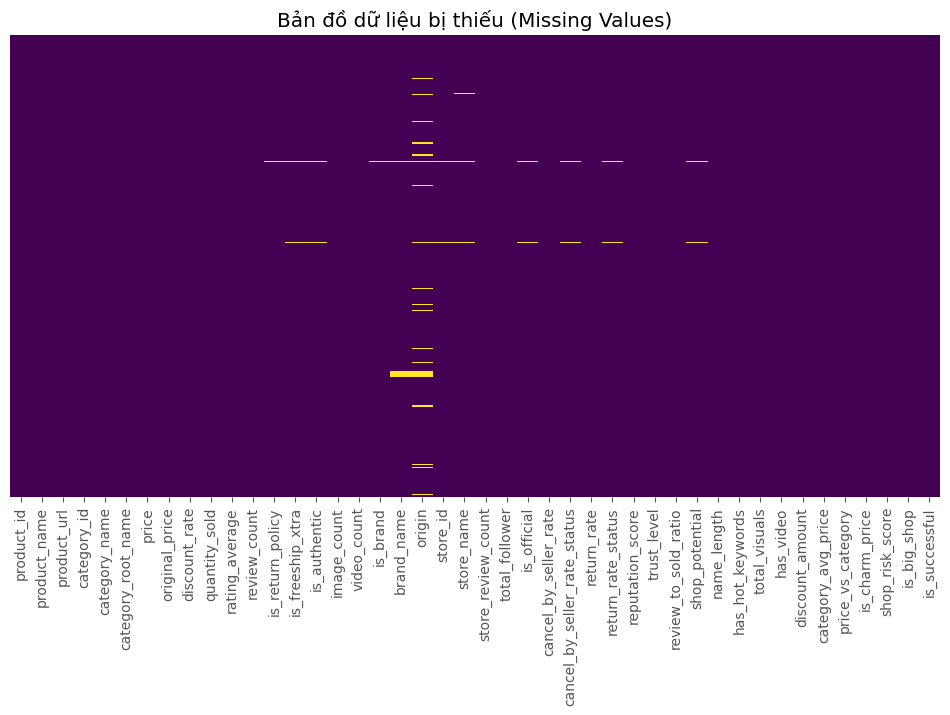

⚠️ Các cột thiếu dữ liệu nghiêm trọng (>50%): []


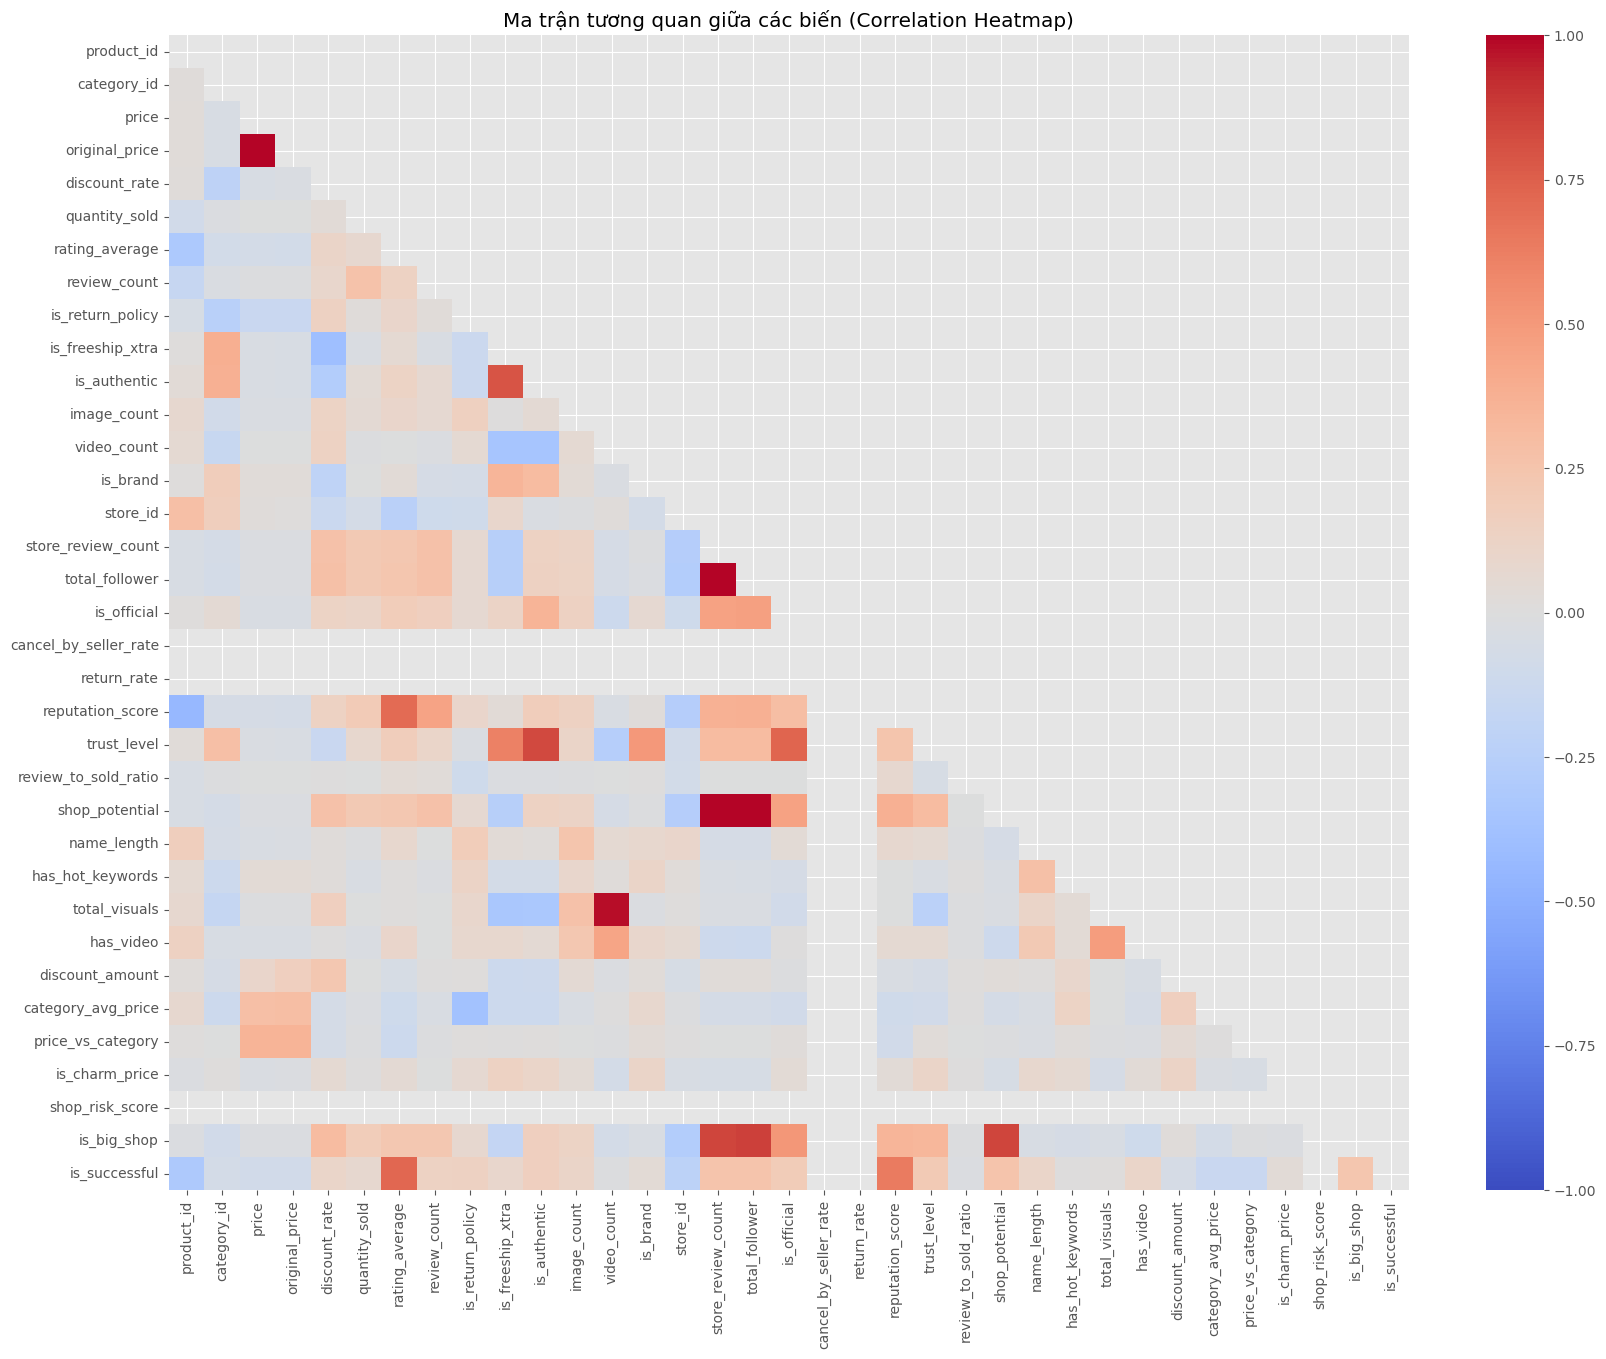


🔍 CÁC CẶP FEATURE TƯƠNG QUAN QUÁ CAO (> 0.9):
- original_price <--> price: 1.00
- total_follower <--> store_review_count: 1.00
- shop_potential <--> store_review_count: 1.00
- shop_potential <--> total_follower: 1.00
- total_visuals <--> video_count: 0.98


d:\PROGRAM FILE\Anaconda\envs\min_ds-env\Lib\site-packages\numpy\lib\function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
d:\PROGRAM FILE\Anaconda\envs\min_ds-env\Lib\site-packages\numpy\lib\function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
C:\Users\chiph\AppData\Local\Temp\ipykernel_20088\3714678673.py:74: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=target_corr.values, y=target_corr.index, palette="magma")


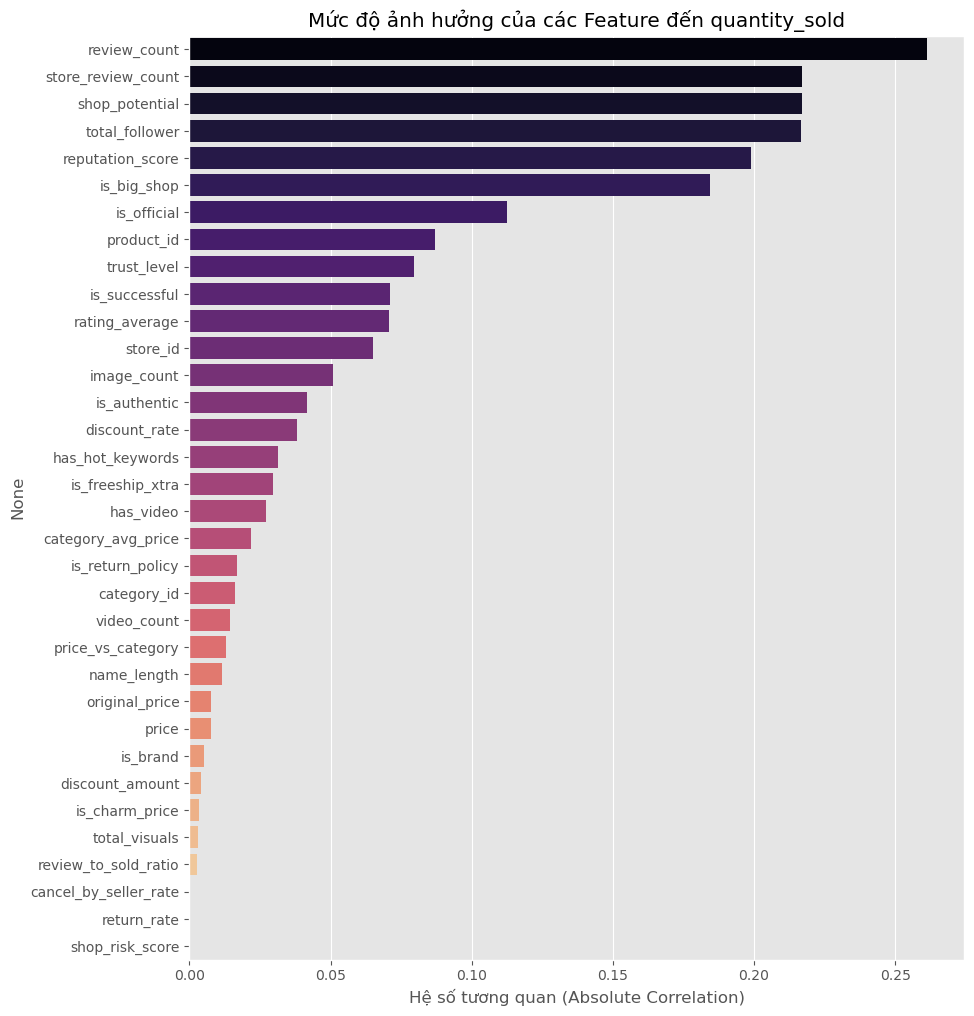


🗑️ Các cột ít có giá trị dự đoán (Corr < 0.01): ['original_price', 'price', 'is_brand', 'discount_amount', 'is_charm_price', 'total_visuals', 'review_to_sold_ratio']

💀 Các cột 'chết' (Giá trị không đổi ở mọi dòng): ['cancel_by_seller_rate', 'return_rate', 'shop_risk_score']


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Cấu hình hiển thị
plt.style.use('ggplot')
pd.set_option('display.max_columns', None)


print("📊 BẮT ĐẦU TRỰC QUAN HÓA DỮ LIỆU ĐỂ SELECTION...")

# ==============================================================================
# BƯỚC 1: KIỂM TRA ĐỘ TIN CẬY (MISSING VALUES)
# Quyết định: Cột nào thiếu > 50% -> DROP NGAY
# ==============================================================================
plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Bản đồ dữ liệu bị thiếu (Missing Values)')
plt.show()

# In ra tỉ lệ thiếu cụ thể
missing_ratio = df.isnull().mean() * 100
cols_to_drop_missing = missing_ratio[missing_ratio > 50].index.tolist()
print(f"⚠️ Các cột thiếu dữ liệu nghiêm trọng (>50%): {cols_to_drop_missing}")


# ==============================================================================
# BƯỚC 2: KIỂM TRA ĐA CỘNG TUYẾN (CORRELATION HEATMAP)
# Quyết định: Nếu 2 cột tương quan > 0.9 -> Chúng là "anh em sinh đôi" -> DROP 1 CỘT
# ==============================================================================

# Chỉ lấy các cột số (loại bỏ string/object)
numeric_df = df.select_dtypes(include=[np.number])

# Tính ma trận tương quan
corr_matrix = numeric_df.corr()

plt.figure(figsize=(20, 15))
# Vẽ heatmap, chỉ hiện một nửa tam giác để dễ nhìn
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=False, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Ma trận tương quan giữa các biến (Correlation Heatmap)')
plt.show()

# --- TỰ ĐỘNG GỢI Ý CỘT CẦN BỎ DO TRÙNG LẶP ---
print("\n🔍 CÁC CẶP FEATURE TƯƠNG QUAN QUÁ CAO (> 0.9):")
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if abs(corr_matrix.iloc[i, j]) > 0.9:
            colname_i = corr_matrix.columns[i]
            colname_j = corr_matrix.columns[j]
            print(f"- {colname_i} <--> {colname_j}: {corr_matrix.iloc[i, j]:.2f}")
            high_corr_pairs.append(colname_i) # Gợi ý bỏ cột sau


# ==============================================================================
# BƯỚC 3: XEM TƯƠNG QUAN VỚI BIẾN MỤC TIÊU (TARGET CORRELATION)
# Quyết định: Cột nào tương quan quá thấp (< 0.01) -> VÔ DỤNG -> DROP
# ==============================================================================

target = 'quantity_sold' # Hoặc 'is_successful'
if target in numeric_df.columns:
    # Tính tương quan của các biến với Target
    target_corr = numeric_df.corrwith(numeric_df[target]).abs().sort_values(ascending=False)
    
    # Bỏ chính nó ra
    target_corr = target_corr.drop(target)
    
    plt.figure(figsize=(10, 12))
    sns.barplot(x=target_corr.values, y=target_corr.index, palette="magma")
    plt.title(f'Mức độ ảnh hưởng của các Feature đến {target}')
    plt.xlabel('Hệ số tương quan (Absolute Correlation)')
    plt.show()
    
    # Gợi ý bỏ cột ít tác dụng
    useless_cols = target_corr[target_corr < 0.01].index.tolist()
    print(f"\n🗑️ Các cột ít có giá trị dự đoán (Corr < 0.01): {useless_cols}")


# ==============================================================================
# BƯỚC 4: KIỂM TRA PHƯƠNG SAI (VARIANCE)
# Quyết định: Cột nào giá trị 100% giống nhau (Variance = 0) -> DROP
# ==============================================================================
low_variance_cols = []
for col in numeric_df.columns:
    if numeric_df[col].std() == 0:
        low_variance_cols.append(col)

print(f"\n💀 Các cột 'chết' (Giá trị không đổi ở mọi dòng): {low_variance_cols}")

review_count và store_review_count có mức độ ảnh hưởng (correlation) cao nhất đến quantity_sold. Đây là những tính năng quan trọng cần giữ lại.

original_price, price, is_brand, discount_amount, is_charm_price, total_visuals, review_to_sold_ratio có hệ số tương quan rất thấp (< 0.01). Đây là những ứng viên tiềm năng để loại bỏ.

cancel_by_seller_rate, return_rate, shop_risk_score không hiển thị thanh correlation nào, có nghĩa là chúng có giá trị không đổi (variance = 0) hoặc toàn là 0. Những cột này chắc chắn phải loại bỏ.

In [9]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Giả sử df là DataFrame hiện tại của bạn (đã scale và đầy đủ feature)
# df = pd.read_csv("tiki_data_scaled_ready.csv")

print("🏁 BƯỚC CUỐI: LỰA CHỌN FEATURES DỰA TRÊN TRỰC QUAN HÓA")

# ==============================================================================
# 1. DANH SÁCH CÁC CỘT CẦN LOẠI BỎ (DROP)
# ==============================================================================
cols_to_drop = [
    # --- Nhóm 1: Định danh & Text (Không có giá trị dự đoán) ---
    'product_id', 'product_name', 'product_url', 
    'category_id', 'category_name', 
    'store_id', 'store_name', 'seller_id', 
    'brand_name', 'origin', 
    
    # --- Nhóm 2: Dữ liệu thô dạng chuỗi/status ---
    'cancel_by_seller_rate_status', 'return_rate_status',

    # --- Nhóm 3: Các cột "Chết" (Variance = 0) hoặc Corr quá thấp (< 0.01) ---
    # Dựa trên biểu đồ bạn cung cấp:
    'shop_risk_score',       # Corr = 0
    'cancel_by_seller_rate',        # Corr = 0 (tương đương cancel_rate)
    'return_rate',        # Corr = 0 (tương đương return_rate)
    'review_to_sold_ratio',  # Corr rất thấp
    'total_visuals',         # Corr rất thấp
    'is_charm_price',        # Corr rất thấp
    'discount_amount',       # Corr rất thấp
    'is_brand',              # Corr rất thấp
    
    # --- Nhóm 4: Loại bỏ đa cộng tuyến (Giữ lại 1 đại diện tốt nhất) ---
    # price và original_price tương quan cực cao -> Bỏ cả 2 gốc, giữ price_scaled hoặc price_vs_category
    'price', 
    'original_price',
    # Bỏ các cột gốc đã được scale
    'quantity_sold', 'total_follower', 'review_count', 'store_review_count', 
    'image_count', 'video_count', 'rating_average', 'reputation_score', 'estimated_revenue'
]

# Tạo DataFrame sạch cho Model
# errors='ignore' để không lỗi nếu lỡ cột không có
df_model = df.drop(columns=cols_to_drop, errors='ignore')

🏁 BƯỚC CUỐI: LỰA CHỌN FEATURES DỰA TRÊN TRỰC QUAN HÓA


In [11]:
# ==============================================================================
# 2. ONE-HOT ENCODING (Xử lý biến phân loại)
# ==============================================================================
# Chỉ còn category_root_name là cần one-hot
if 'category_root_name' in df_model.columns:
    # Thêm tham số dtype=int để ép về số 1 và 0
    df_model = pd.get_dummies(
        df_model, 
        columns=['category_root_name'], 
        drop_first=True, 
        dtype=int  
    )
# ==============================================================================
# 3. TÁCH X VÀ y
# ==============================================================================
target_col = 'is_successful' 

# X là tất cả trừ target và các biến leakage (tiết lộ kết quả)
# quantity_sold_scaled cần bỏ vì nó chính là đáp án đã được scale
X = df_model.drop(columns=['is_successful', 'quantity_sold_scaled'], errors='ignore')
y = df[target_col]

# Xử lý NaN lần cuối
X = X.fillna(0)

# ==============================================================================
# 4. CHIA TRAIN/TEST & LƯU FILE
# ==============================================================================
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("-" * 50)
print(f"📊 DỮ LIỆU SẴN SÀNG CHO MODELING:")
print(f"Số lượng features: {X_train.shape[1]}")
print("\n📋 Danh sách Features giữ lại:")
print(list(X_train.columns))

X_train.to_csv("processed/X_train_final.csv", index=False)
y_train.to_csv("processed/y_train_final.csv", index=False)
X_test.to_csv("processed/X_test_final.csv", index=False)
y_test.to_csv("processed/y_test_final.csv", index=False)

--------------------------------------------------
📊 DỮ LIỆU SẴN SÀNG CHO MODELING:
Số lượng features: 35

📋 Danh sách Features giữ lại:
['discount_rate', 'is_return_policy', 'is_freeship_xtra', 'is_authentic', 'is_official', 'trust_level', 'shop_potential', 'name_length', 'has_hot_keywords', 'has_video', 'category_avg_price', 'price_vs_category', 'is_big_shop', 'category_root_name_Bách Hóa Online', 'category_root_name_Chăm sóc nhà cửa', 'category_root_name_Giày - Dép nam', 'category_root_name_Giày - Dép nữ', 'category_root_name_Laptop – Máy Vi Tính – Linh kiện', 'category_root_name_Làm Đẹp - Sức Khỏe', 'category_root_name_Máy Ảnh - Máy Quay Phim', 'category_root_name_NGON', 'category_root_name_Nhà Cửa - Đời Sống', 'category_root_name_Nhà Sách Tiki', 'category_root_name_Phụ kiện thời trang', 'category_root_name_Thiết bị số - Phụ kiện số', 'category_root_name_Thể Thao – Dã Ngoại', 'category_root_name_Thời trang nam', 'category_root_name_Thời trang nữ', 'category_root_name_Túi thời trang